In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model, model_from_json

classes = ["Angry", "Disgust", "Fear", "Happy", "Neutral","Sad","Surprised"]
gender = ['female','male']

In [2]:
json_file = open('model.json', 'r')
model = json_file.read()
json_file.close()
emotion_model = model_from_json(model)
# load weights into new model
emotion_model.load_weights("model_weights.h5")

2022-03-28 18:16:24.659137: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-03-28 18:16:26.327542: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [3]:
gender_model= load_model('gender_model.h5')

In [ ]:
#model = load_model('model_v1.h5')

(7, 48, 48, 1)


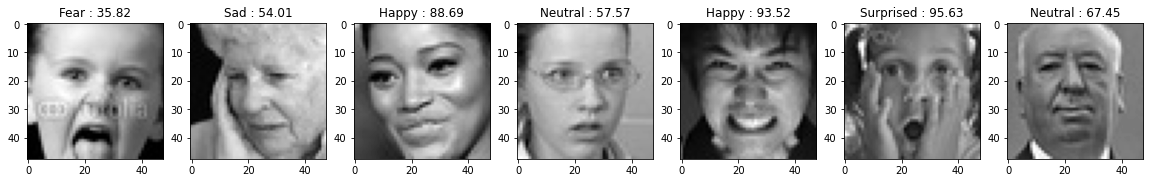

In [18]:
path = 'fer-2013-/test'
test_images = []

for cat_dir in os.listdir(path):
    cat_path = os.path.join(path, cat_dir)
    img_path = os.listdir(cat_path)[np.random.randint(0,100)]
    img_path = os.path.join(cat_path, img_path)
    img = plt.imread(img_path)
    test_images.append(img)
    
test_images = np.array(test_images).reshape(-1,48,48,1)
print(test_images.shape)
predictions = emotion_model.predict(test_images)
plt.figure(figsize=(20,5))
for i in range(len(test_images)):
    plt.subplot(1,7,i+1)
    plt.imshow(test_images[i], cmap='gray')
    p = predictions[i].max()*100.00
    emotion_index = np.argmax(predictions[i])
    emotion_label = classes[emotion_index]
    plt.title("{} : {:.2f}".format(emotion_label, p))

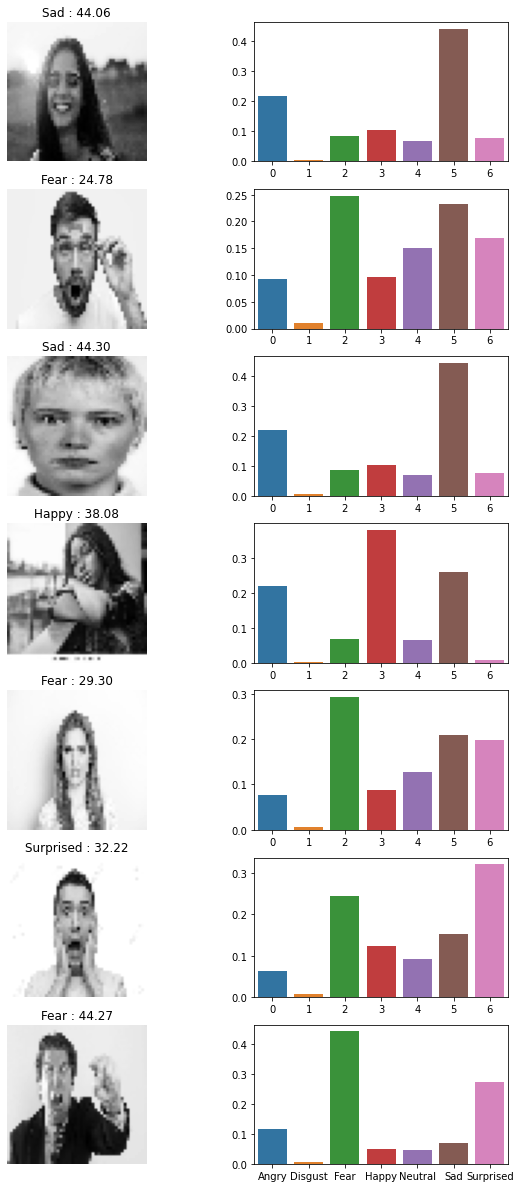

In [7]:
path = 'test_images'
images_list = []

for img_path in os.listdir(path):
    img_path = os.path.join(path, img_path)
    img = plt.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)      
    img = cv2.resize(img, (48,48))
    images_list.append(img)

images_list = np.array(images_list).reshape(-1,48,48,1)
predictions = model.predict(images_list)

# plt.figure(figsize=(15,15))
fig, ax = plt.subplots(7,2, figsize=(10,21))
for i in range(len(images_list)):
    ax[i,0].imshow(images_list[i], cmap='gray')
    p = predictions[i].max()*100.00
    emotion_index = np.argmax(predictions[i])
    emotion_label = classes[emotion_index]
    ax[i,0].set_title("{} : {:.2f}".format(emotion_label, p))
    ax[i,0].axis('off')
    
for i in range(len(images_list)):  
    sns.barplot(ax=ax[i,1], x=np.arange(7), y=predictions[i])
    plt.xticks(np.arange(7),classes)
plt.show()

In [11]:
# Load the cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# To capture video from webcam. 
cap = cv2.VideoCapture(0)

# To use a video file as input 
# cap = cv2.VideoCapture('filename.mp4')

while True:
    #read the frame
    _,img = cap.read()
    #convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #detect the faces
    faces = face_cascade.detectMultiScale(gray, 1.1, 1)
    #draw rectangle around face
    for (x,y,w,h) in faces:
        # face retangle
        cv2.rectangle(img, (x,y), (x+w, y+h), (255,0,0), 2)        
        gray_scale = gray[y:y+h, x:x+h]
        
        gray_48 = cv2.resize(gray_scale, (48,48))
        emotion_pixels = image.img_to_array(gray_48)
        emotion_pixels = np.expand_dims(emotion_pixels, axis=0)
        #predict emotion
        emotion_predictions = emotion_model.predict(emotion_pixels)
        p = emotion_predictions.max()*100
        p = "{:.2f} %".format(p)
        emotion_index = np.argmax(emotion_predictions)
        emotion_label = classes[emotion_index]
        #write the prediction
        cv2.putText(img, emotion_label, (x-5,y-40) ,cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,250,50), 2)
        cv2.putText(img, p, (x+x//2,y-40) ,cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,250,100), 1)
        

        gray_64 = cv2.resize(gray_scale, (64,64))
        gender_pixels = image.img_to_array(gray_64)
        gender_pixels = np.expand_dims(gender_pixels, axis=0)
        #predict gender
        gender_predictions = gender_model.predict(gender_pixels)
        p2 = gender_predictions.max()*100
        p2 = "{:.2f} %".format(p2)
        gender_index = np.argmax(gender_predictions)
        gender_label = gender[gender_index]
        #write the prediction
        cv2.putText(img, gender_label, (x-5,y-15) ,cv2.FONT_HERSHEY_SIMPLEX, 0.7, (25,250,50), 2)
        cv2.putText(img, p2, (x+x//2,y-15) ,cv2.FONT_HERSHEY_SIMPLEX, 0.6, (25,250,150), 1)
        
    #display
    cv2.imshow('face detection', img)
    #stop if 'esc' key pressed
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break
    
#release the VideoCapture objet
cap.release()
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to target thread (0x5580301cae00)

QObject::moveToThread: Current thread (0x5580301cae00) is not the object's thread (0x5580300dfbe0).
Cannot move to tar

2022-03-28 18:16:43.174898: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2022-03-28 18:16:45.327996: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 1995195000 Hz


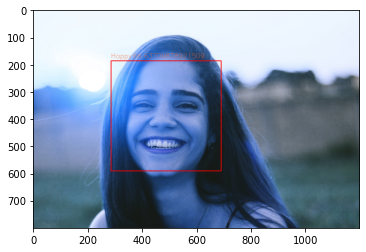

In [4]:
import cv2

# Load the cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
# Read the input image
img = cv2.imread('test_images/1_HEoLBLidT2u4mhJ0oiDgig.png')
# Convert into grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
# Draw rectangle around the faces
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    gray_scale = gray[x:x+w, y:y+h]
    gray_scale = cv2.resize(gray_scale, (48,48))
    pixels = image.img_to_array(gray_scale)
    pixels = np.expand_dims(pixels, axis=0)
    pred = emotion_model.predict(pixels)
    p = np.max(pred)*100
    index = np.argmax(pred)
    emotio_label = classes[index]
    cv2.putText(img, emotio_label, (x,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,100,50), 1)
    cv2.putText(img, str(p), (x+80,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,100,50), 1)

plt.imshow(img)
# Display the output
# cv2.imshow('img', img)
# cv2.waitKey()